⏳ 1. Memuat Data Training (Hasil Split Tahap 04)...
⏳ 2. Menganalisis distribusi kelas awal...
   Aman semua (minoritas)  : 3,635
   Berisiko ≥1 (mayoritas) : 18,105
   Rasio Imbalance         : 1 : 4.98
⏳ 3. Menjalankan Undersampling pada kelas mayoritas...
   Mayoritas setelah undersample : 4,362
⏳ 4. Menjalankan MLSMOTE pada kelas minoritas...
   Akan digenerate 727 data sintetis untuk menutup gap...
   -> Ditemukan 3,635 responden 'Aman Semua' (minoritas) untuk di-oversample.



### ⚖️ Tahap 05: Multi-label Imbalance Handling Selesai
---
Strategi **Combined Sampling** (Undersampling mayoritas + MLSMOTE minoritas) telah diterapkan
untuk mencapai distribusi kelas yang jauh lebih seimbang.

**Strategi yang Digunakan:**
* **Step 1 — Undersampling:** Kelas mayoritas (Berisiko ≥1 label) dikurangi ke target **1.5× jumlah minoritas**.
* **Step 2 — MLSMOTE:** Kelas minoritas (Aman semua label) di-oversample menggunakan interpolasi k-NN.
* **Rasio Target:** ≈ 1 : 1.5 (realistis, tidak terlalu artificial).

**Statistik Perubahan:**

| Kondisi | Sebelum (Minoritas) | Sebelum (Mayoritas) | Sesudah (Aman) | Sesudah (Berisiko) |
| :--- | ---: | ---: | ---: | ---: |
| **Depresi** | 6,372 | 15,368 | **5,037** | **3,687** |
| **Ansietas** | 5,766 | 15,974 | **4,849** | **3,875** |
| **Stres** | 8,526 | 13,214 | **5,572** | **3,152** |

**Ukuran Data:**
* Jumlah Data Awal     : **21,740** baris
* Jumlah Data Akhir    : **8,724** baris
* Data Sintetis Dibuat : **+727** baris

✅ *Dataset seimbang tersimpan di `Data/processed/train_balanced_multilabel.csv`. Siap untuk Tahap 06: Seleksi Fitur MFO.*


🎨 Membuat Visualisasi Perbandingan Distribusi Kelas...


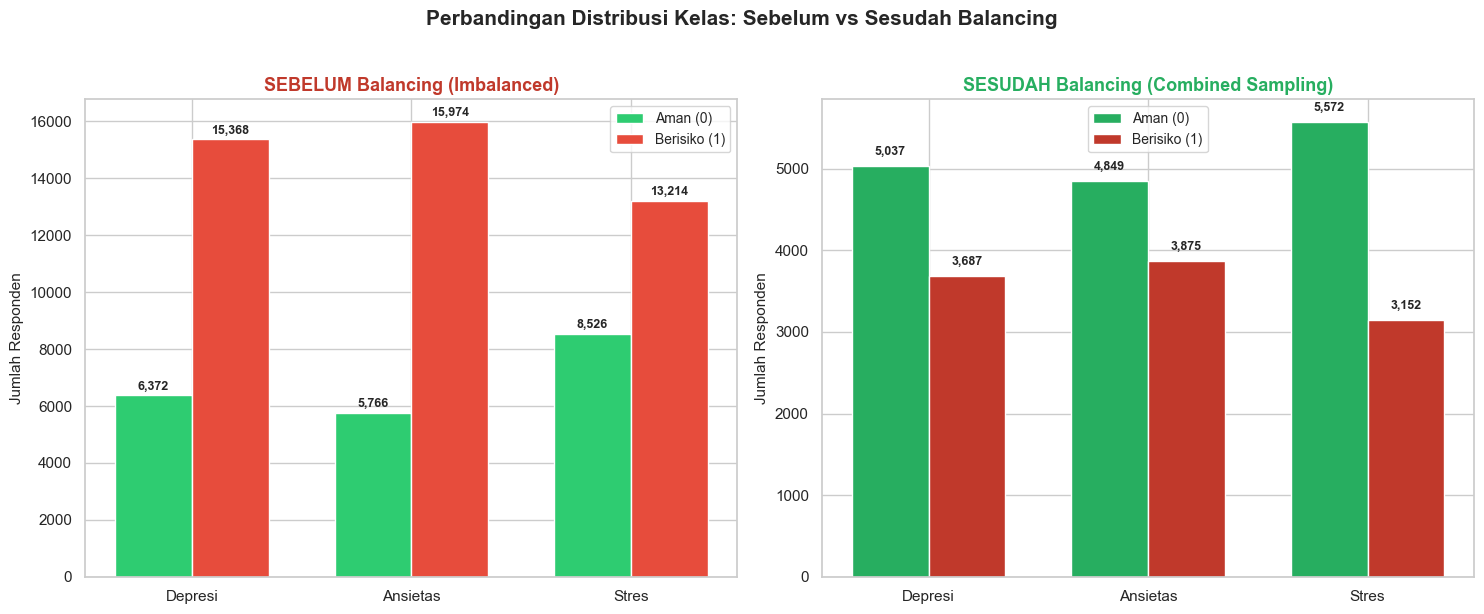

✅ Grafik 1: Perbandingan distribusi kelas berhasil disimpan.


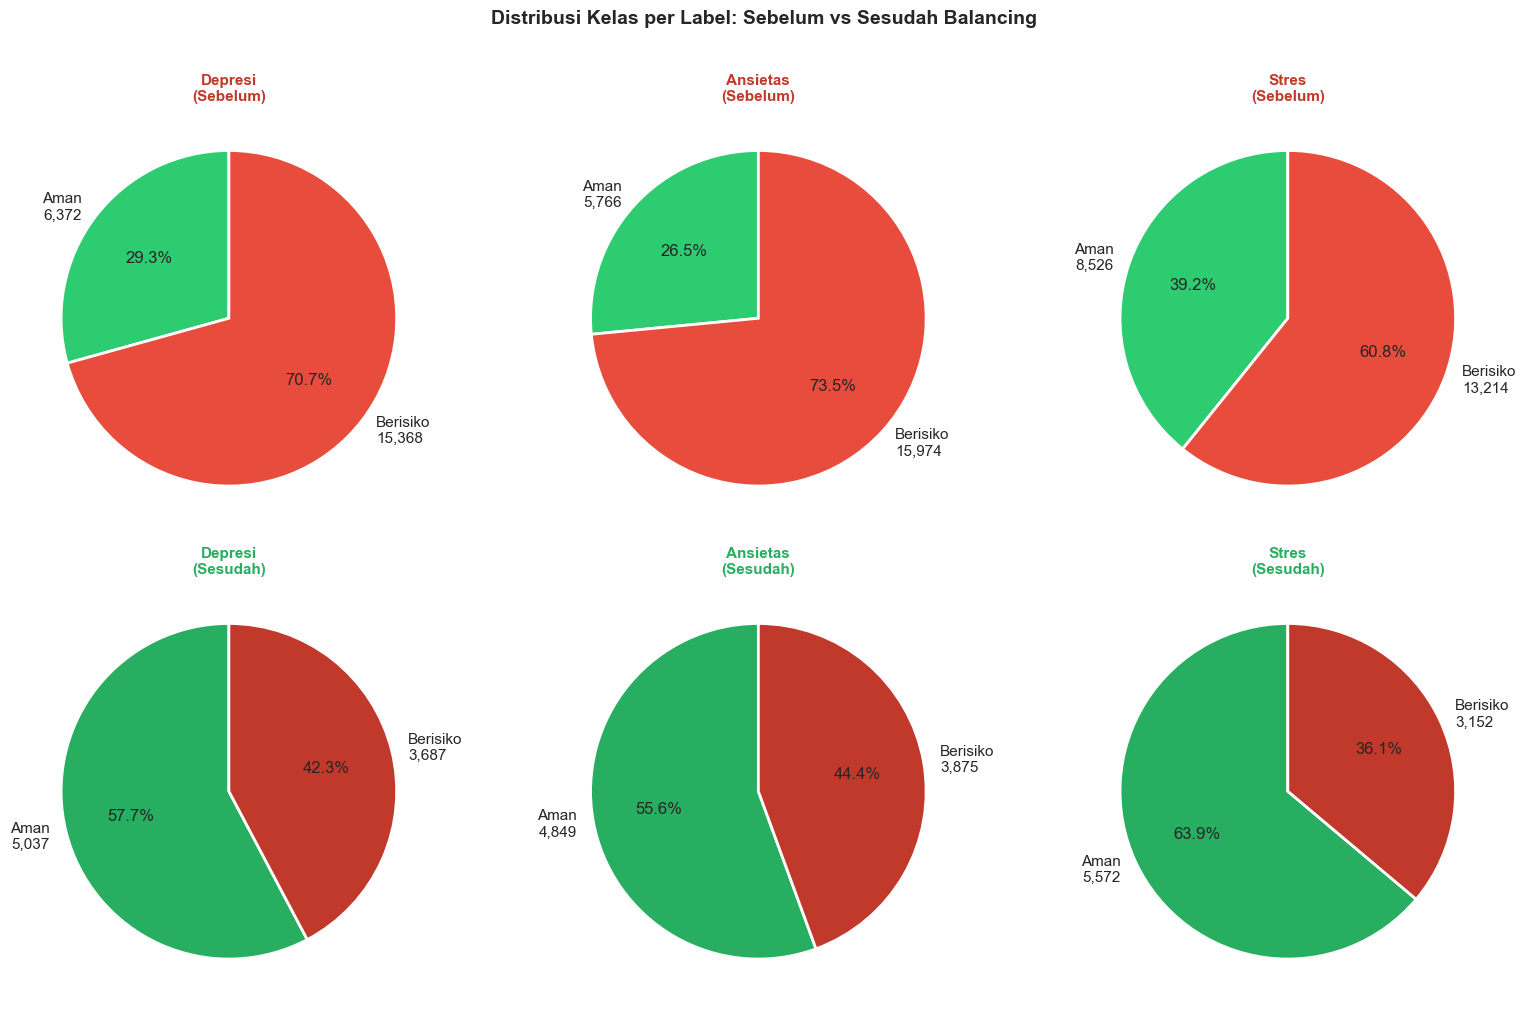

✅ Grafik 2: Pie chart distribusi kelas berhasil disimpan.


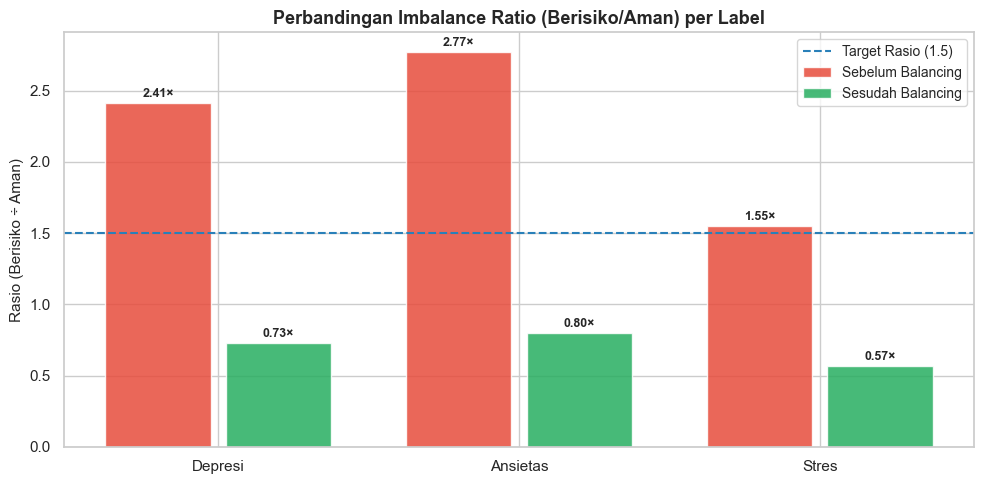

✅ Grafik 3: Imbalance ratio comparison berhasil disimpan.

✅ Semua visualisasi tersimpan di folder 'outputs/imbalance_figures/' dan di-log ke MLflow.


In [5]:
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.neighbors import NearestNeighbors
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP PATH & MLFLOW
# ==========================================
root_path = Path.cwd().parent
mlflow.set_tracking_uri((root_path / "mlruns").as_uri())
mlflow.set_experiment("05_Multi_label_Imbalance")

# ==========================================
# 2. FUNGSI MLSMOTE (DIPERBAIKI)
# ==========================================
def get_mlsmote(X, y, n_synthetic, k=5):
    """
    MLSMOTE untuk oversample kelas minoritas.
    Minoritas didefinisikan sebagai baris yang AMAN (0) di SEMUA label sekaligus.
    FIX: nn.fit(X.values) untuk menghindari warning feature names mismatch.
    """
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(X.values)  # FIX: gunakan .values untuk hindari warning

    new_X, new_y = [], []

    # Identifikasi minoritas: Aman di SEMUA label (AND bukan OR)
    minority_mask = (y['risk_depression'] == 0) & \
                    (y['risk_anxiety'] == 0) & \
                    (y['risk_stress'] == 0) 
    minority_indices = y[minority_mask].index.tolist()

    print(f"   -> Ditemukan {len(minority_indices):,} responden 'Aman Semua' (minoritas) untuk di-oversample.")

    for i in range(n_synthetic):
        idx = np.random.choice(minority_indices)
        iloc_idx = X.index.get_loc(idx)
        sample_x = X.iloc[iloc_idx].values
        sample_y = y.iloc[iloc_idx].values

        neighbors = nn.kneighbors([sample_x], return_distance=False)[0]
        neighbor_idx = np.random.choice(neighbors)
        neighbor_x = X.iloc[neighbor_idx].values

        step = np.random.uniform(0, 1)
        gen_x = sample_x + step * (neighbor_x - sample_x)

        new_X.append(gen_x)
        new_y.append(sample_y)

    return pd.DataFrame(new_X, columns=X.columns), pd.DataFrame(new_y, columns=y.columns)


with mlflow.start_run(run_name="MLSMOTE_Combined_Sampling"):

    # ==========================================
    # 3. LOAD DATA
    # ==========================================
    print("⏳ 1. Memuat Data Training (Hasil Split Tahap 04)...")
    train_df = pd.read_csv(root_path / "Data/split/train_data.csv")

    target_cols = ['risk_depression', 'risk_anxiety', 'risk_stress']
    X_train = train_df.drop(columns=target_cols)
    Y_train = train_df[target_cols]

    # ==========================================
    # 4. ANALISIS DISTRIBUSI AWAL
    # ==========================================
    print("⏳ 2. Menganalisis distribusi kelas awal...")

    # Minoritas = Aman di SEMUA label (AND)
    minority_mask = (Y_train['risk_depression'] == 0) & \
                    (Y_train['risk_anxiety'] == 0) & \
                    (Y_train['risk_stress'] == 0)
    majority_mask = ~minority_mask

    minority_count = minority_mask.sum()
    majority_count = majority_mask.sum()

    print(f"   Aman semua (minoritas)  : {minority_count:,}")
    print(f"   Berisiko ≥1 (mayoritas) : {majority_count:,}")
    print(f"   Rasio Imbalance         : 1 : {majority_count/minority_count:.2f}")

    # ==========================================
    # 5. STEP 1 - UNDERSAMPLE MAYORITAS
    # ==========================================
    print("⏳ 3. Menjalankan Undersampling pada kelas mayoritas...")

    # Target mayoritas = 1.5x minoritas (rasio yang masih realistis)
    target_majority = int(minority_count * 1.2)
    X_majority = X_train[majority_mask].sample(n=target_majority, random_state=42)
    Y_majority = Y_train.loc[X_majority.index]

    X_minority = X_train[minority_mask]
    Y_minority = Y_train[minority_mask]

    print(f"   Mayoritas setelah undersample : {target_majority:,}")

    # ==========================================
    # 6. STEP 2 - OVERSAMPLE MINORITAS (MLSMOTE)
    # ==========================================
    print("⏳ 4. Menjalankan MLSMOTE pada kelas minoritas...")

    n_synthetic = target_majority - minority_count
    print(f"   Akan digenerate {n_synthetic:,} data sintetis untuk menutup gap...")

    X_res, Y_res = get_mlsmote(X_minority, Y_minority, n_synthetic)

    # ==========================================
    # 7. STEP 3 - GABUNGKAN SEMUA DATA
    # ==========================================
    X_train_final = pd.concat([
        X_majority.reset_index(drop=True),
        X_minority.reset_index(drop=True),
        X_res.reset_index(drop=True)
    ], axis=0).reset_index(drop=True)

    Y_train_final = pd.concat([
        Y_majority.reset_index(drop=True),
        Y_minority.reset_index(drop=True),
        Y_res.reset_index(drop=True)
    ], axis=0).reset_index(drop=True)

    n_synthetic_total = len(X_train_final) - len(X_train)

    # ==========================================
    # 8. SIMPAN DATA HASIL
    # ==========================================
    train_balanced_df = pd.concat([X_train_final, Y_train_final], axis=1)
    output_path = root_path / "Data/processed/train_balanced_multilabel.csv"
    output_path.parent.mkdir(parents=True, exist_ok=True)
    train_balanced_df.to_csv(output_path, index=False)

    # ==========================================
    # 9. LOGGING KE MLFLOW
    # ==========================================
    mlflow.log_param("sampling_strategy", "Undersample Mayoritas + MLSMOTE Minoritas")
    mlflow.log_param("target_ratio", "1:1.5")
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("original_size", len(X_train))
    mlflow.log_metric("final_balanced_size", len(X_train_final))
    mlflow.log_metric("n_synthetic_added", len(X_res))
    mlflow.log_metric("minority_before", int(minority_count))
    mlflow.log_metric("majority_before", int(majority_count))
    mlflow.log_metric("minority_after", int(Y_train_final[~((Y_train_final['risk_depression']==1)|(Y_train_final['risk_anxiety']==1)|(Y_train_final['risk_stress']==1))].shape[0] + len(X_res)))
    mlflow.log_metric("majority_after", target_majority)

    # ==========================================
    # 10. SUMMARY OUTPUT
    # ==========================================
    # Rasio akhir per label
    dep_aman  = int(len(Y_train_final) - Y_train_final['risk_depression'].sum())
    dep_risk  = int(Y_train_final['risk_depression'].sum())
    anx_aman  = int(len(Y_train_final) - Y_train_final['risk_anxiety'].sum())
    anx_risk  = int(Y_train_final['risk_anxiety'].sum())
    str_aman  = int(len(Y_train_final) - Y_train_final['risk_stress'].sum())
    str_risk  = int(Y_train_final['risk_stress'].sum())

    summary = f"""
### ⚖️ Tahap 05: Multi-label Imbalance Handling Selesai
---
Strategi **Combined Sampling** (Undersampling mayoritas + MLSMOTE minoritas) telah diterapkan
untuk mencapai distribusi kelas yang jauh lebih seimbang.

**Strategi yang Digunakan:**
* **Step 1 — Undersampling:** Kelas mayoritas (Berisiko ≥1 label) dikurangi ke target **1.5× jumlah minoritas**.
* **Step 2 — MLSMOTE:** Kelas minoritas (Aman semua label) di-oversample menggunakan interpolasi k-NN.
* **Rasio Target:** ≈ 1 : 1.5 (realistis, tidak terlalu artificial).

**Statistik Perubahan:**

| Kondisi | Sebelum (Minoritas) | Sebelum (Mayoritas) | Sesudah (Aman) | Sesudah (Berisiko) |
| :--- | ---: | ---: | ---: | ---: |
| **Depresi** | {len(Y_train) - int(Y_train['risk_depression'].sum()):,} | {int(Y_train['risk_depression'].sum()):,} | **{dep_aman:,}** | **{dep_risk:,}** |
| **Ansietas** | {len(Y_train) - int(Y_train['risk_anxiety'].sum()):,} | {int(Y_train['risk_anxiety'].sum()):,} | **{anx_aman:,}** | **{anx_risk:,}** |
| **Stres** | {len(Y_train) - int(Y_train['risk_stress'].sum()):,} | {int(Y_train['risk_stress'].sum()):,} | **{str_aman:,}** | **{str_risk:,}** |

**Ukuran Data:**
* Jumlah Data Awal     : **{len(X_train):,}** baris
* Jumlah Data Akhir    : **{len(X_train_final):,}** baris
* Data Sintetis Dibuat : **+{len(X_res):,}** baris

✅ *Dataset seimbang tersimpan di `Data/processed/train_balanced_multilabel.csv`. Siap untuk Tahap 06: Seleksi Fitur MFO.*
"""
    display(Markdown(summary))

    # ==========================================
    # 11. VISUALISASI EDA — SEBELUM vs SESUDAH
    # ==========================================
    print("🎨 Membuat Visualisasi Perbandingan Distribusi Kelas...")

    sns.set_theme(style="whitegrid", palette="muted")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Perbandingan Distribusi Kelas: Sebelum vs Sesudah Balancing',
                 fontsize=15, fontweight='bold', y=1.02)

    label_names = ['Depresi', 'Ansietas', 'Stres']
    x = np.arange(len(label_names))
    width = 0.35

    # --- Data SEBELUM ---
    aman_before  = [len(Y_train) - Y_train['risk_depression'].sum(),
                    len(Y_train) - Y_train['risk_anxiety'].sum(),
                    len(Y_train) - Y_train['risk_stress'].sum()]
    risiko_before = [Y_train['risk_depression'].sum(),
                     Y_train['risk_anxiety'].sum(),
                     Y_train['risk_stress'].sum()]

    # --- Data SESUDAH ---
    aman_after  = [dep_aman, anx_aman, str_aman]
    risiko_after = [dep_risk, anx_risk, str_risk]

    # --- PLOT KIRI: SEBELUM ---
    b1 = axes[0].bar(x - width/2, aman_before,  width, label='Aman (0)',     color='#2ecc71', edgecolor='white')
    b2 = axes[0].bar(x + width/2, risiko_before, width, label='Berisiko (1)', color='#e74c3c', edgecolor='white')
    axes[0].set_title('SEBELUM Balancing (Imbalanced)', fontsize=13, fontweight='bold', color='#c0392b')
    axes[0].set_ylabel('Jumlah Responden', fontsize=11)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(label_names, fontsize=11)
    axes[0].legend(fontsize=10)
    # Angka di atas bar
    for bar in b1:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in b2:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # --- PLOT KANAN: SESUDAH ---
    b3 = axes[1].bar(x - width/2, aman_after,  width, label='Aman (0)',     color='#27ae60', edgecolor='white')
    b4 = axes[1].bar(x + width/2, risiko_after, width, label='Berisiko (1)', color='#c0392b', edgecolor='white')
    axes[1].set_title('SESUDAH Balancing (Combined Sampling)', fontsize=13, fontweight='bold', color='#27ae60')
    axes[1].set_ylabel('Jumlah Responden', fontsize=11)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(label_names, fontsize=11)
    axes[1].legend(fontsize=10)
    # Angka di atas bar
    for bar in b3:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in b4:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()

    output_dir = root_path / "outputs" / "imbalance_figures"
    output_dir.mkdir(parents=True, exist_ok=True)
    fig_path = output_dir / "mlsmote_comparison.png"
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(str(fig_path))
    plt.show()
    print("✅ Grafik 1: Perbandingan distribusi kelas berhasil disimpan.")

    # ==========================================
    # 12. VISUALISASI EDA — RASIO IMBALANCE (PIE CHART)
    # ==========================================
    fig2, axes2 = plt.subplots(2, 3, figsize=(16, 10))
    fig2.suptitle('Distribusi Kelas per Label: Sebelum vs Sesudah Balancing',
                  fontsize=14, fontweight='bold', y=1.01)

    pie_colors = ['#2ecc71', '#e74c3c']
    kondisi_list = ['Depresi', 'Ansietas', 'Stres']

    data_before = [
        [len(Y_train) - int(Y_train['risk_depression'].sum()), int(Y_train['risk_depression'].sum())],
        [len(Y_train) - int(Y_train['risk_anxiety'].sum()),    int(Y_train['risk_anxiety'].sum())],
        [len(Y_train) - int(Y_train['risk_stress'].sum()),     int(Y_train['risk_stress'].sum())],
    ]
    data_after = [
        [dep_aman, dep_risk],
        [anx_aman, anx_risk],
        [str_aman, str_risk],
    ]

    for i, kondisi in enumerate(kondisi_list):
        # Baris atas = SEBELUM
        vals_b = data_before[i]
        axes2[0][i].pie(
            vals_b,
            labels=[f'Aman\n{vals_b[0]:,}', f'Berisiko\n{vals_b[1]:,}'],
            colors=pie_colors,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        axes2[0][i].set_title(f'{kondisi}\n(Sebelum)', fontsize=11, fontweight='bold', color='#c0392b')

        # Baris bawah = SESUDAH
        vals_a = data_after[i]
        axes2[1][i].pie(
            vals_a,
            labels=[f'Aman\n{vals_a[0]:,}', f'Berisiko\n{vals_a[1]:,}'],
            colors=['#27ae60', '#c0392b'],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}
        )
        axes2[1][i].set_title(f'{kondisi}\n(Sesudah)', fontsize=11, fontweight='bold', color='#27ae60')

    plt.tight_layout()
    fig2_path = output_dir / "pie_class_distribution.png"
    plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(str(fig2_path))
    plt.show()
    print("✅ Grafik 2: Pie chart distribusi kelas berhasil disimpan.")

    # ==========================================
    # 13. VISUALISASI EDA — IMBALANCE RATIO PROGRESSION
    # ==========================================
    fig3, ax3 = plt.subplots(figsize=(10, 5))

    rasio_before = [vals_b[1]/vals_b[0] for vals_b in data_before]
    rasio_after  = [vals_a[1]/vals_a[0] for vals_a in data_after]

    xp = np.arange(3)
    bars_b = ax3.bar(xp - 0.2, rasio_before, 0.35, label='Sebelum Balancing', color='#e74c3c', alpha=0.85, edgecolor='white')
    bars_a = ax3.bar(xp + 0.2, rasio_after,  0.35, label='Sesudah Balancing',  color='#27ae60', alpha=0.85, edgecolor='white')

    ax3.axhline(y=1.5, color='#2980b9', linestyle='--', linewidth=1.5, label='Target Rasio (1.5)')
    ax3.set_title('Perbandingan Imbalance Ratio (Berisiko/Aman) per Label', fontsize=13, fontweight='bold')
    ax3.set_ylabel('Rasio (Berisiko ÷ Aman)', fontsize=11)
    ax3.set_xticks(xp)
    ax3.set_xticklabels(kondisi_list, fontsize=11)
    ax3.legend(fontsize=10)

    for bar in bars_b:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in bars_a:
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}×', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    fig3_path = output_dir / "imbalance_ratio_comparison.png"
    plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
    mlflow.log_artifact(str(fig3_path))
    plt.show()
    print("✅ Grafik 3: Imbalance ratio comparison berhasil disimpan.")

    print("\n✅ Semua visualisasi tersimpan di folder 'outputs/imbalance_figures/' dan di-log ke MLflow.")